# Event 05 — 러-우 전쟁 & 원자재 쇼크 (2022.02)
## 스토리텔링 차트 (Scrollytelling Stepper)

### 배경
2022년 2월 24일, 러시아가 우크라이나를 침공. 세계 3대 원유 생산국의 전쟁은 **WTI를 $92 → $130(장중 고점)**으로 밀어올렸고, **이미 6~7%대였던 인플레이션에 기름을 부었다**. Fed의 긴축 압박도 덩달아 강해지며 2022년 전체 하락장의 기폭제가 됐다.

### 출력
- `data/figures/e05_story/00_prologue.png` … `04_act4.png`
- `data/figures/e05_story/99_summary.png`

## 1. Imports & 데이터 로드

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
PANEL = ROOT / 'data' / 'processed' / 'panel_daily.csv'
FIG_DIR = ROOT / 'data' / 'figures' / 'e05_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PANEL, index_col=0, parse_dates=True)
df = df.loc['2022-01-18':'2022-06-15', ['WTI', 'SP500']].copy()
print(f'shape: {df.shape}, {df.index.min().date()} ~ {df.index.max().date()}')
print(f'WTI max: ${df.WTI.max():.2f} on {df.WTI.idxmax().date()}')
print(f'SP500 min: ${df.SP500.min():.0f} on {df.SP500.idxmin().date()}')

shape: (107, 2), 2022-01-18 ~ 2022-06-15
WTI max: $123.64 on 2022-03-08
SP500 min: $3735 on 2022-06-14


## 2. 5국면 정의

In [2]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 긴장 고조',
        'start': '2022-01-18', 'end': '2022-02-18', 'color': '#90A4AE',
        'narrative': '러시아 국경에 대규모 병력 집결. WTI는 $85→$91로 꾸준히 상승, SP500은 긴축 우려와 지정학 리스크가 겹치며 -5% 하락.',
        'hero_annotations': [
            ('2022-01-18', 'WTI',   85.42, 'WTI $85\n(긴장 시작)', (-55, 25), 'left'),
            ('2022-02-18', 'SP500', 4349,  'SP500 -5%\n(지정학 우려)', (-90, -30), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — 침공 개시 (2/24)',
        'start': '2022-02-22', 'end': '2022-02-24', 'color': '#E53935',
        'narrative': '2022-02-24 러시아가 우크라이나를 침공. WTI는 $92, SP500은 장중 급락 후 4,289로 반등. 시장은 아직 "지정학 사건" 정도로 평가.',
        'hero_annotations': [
            ('2022-02-24', 'WTI',   92.77, '⭐ 침공 개시\nWTI $92.77', (-30, 25), 'left'),
            ('2022-02-24', 'SP500', 4289,  'SP500 장중 급락\n후 반등 마감', (15, -30), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — 공포 랠리 (WTI $123)',
        'start': '2022-02-25', 'end': '2022-03-08', 'color': '#C62828',
        'narrative': '러시아산 원유 제재 논의가 현실화되며 공급 공포가 폭발. **WTI는 3/8 장중 $130**(종가 $123.64)까지 치솟았고 SP500은 4,171까지 밀렸다.',
        'hero_annotations': [
            ('2022-03-08', 'WTI',  123.64, '⭐ WTI 정점\n장중 $130 · 종가 $123.64', (-30, 20), 'left'),
            ('2022-03-08', 'SP500', 4171,  'SP500 저점 -9.5%\n(연초 대비)', (15, -30), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — SPR 방출 & 완화',
        'start': '2022-03-09', 'end': '2022-03-31', 'color': '#4FC3F7',
        'narrative': '바이든이 전략비축유(SPR) 하루 100만 배럴 × 6개월 방출을 발표. WTI는 3월 말 $100으로 진정됐고 SP500은 4,530까지 회복했다.',
        'hero_annotations': [
            ('2022-03-31', 'WTI',  100.53, 'SPR 방출\n100만 b/d × 6개월', (-120, 20), 'left'),
            ('2022-03-31', 'SP500', 4530,  'SP500 회복', (15, 20), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 2차 고공 & 인플레 가속',
        'start': '2022-04-01', 'end': '2022-06-15', 'color': '#6A1B9A',
        'narrative': '공급 차질이 장기화되자 WTI는 6월 다시 $120대로 복귀. CPI는 8~9%대로 치솟고 Fed는 75bp 인상(6/15)으로 대응했다.',
        'hero_annotations': [
            ('2022-06-10', 'WTI',  120.73, 'WTI $120대 복귀\n(6월)', (-120, 20), 'left'),
            ('2022-06-15', 'SP500', 3790,  'SP500 -17%\n(Fed 75bp 인상일)', (15, -25), 'left'),
        ],
    },
]
pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 긴장 고조,2022-01-18,2022-02-18,#90A4AE,"러시아 국경에 대규모 병력 집결. WTI는 $85→$91로 꾸준히 상승, SP500..."
1,act1,Act 1 — 침공 개시 (2/24),2022-02-22,2022-02-24,#E53935,"2022-02-24 러시아가 우크라이나를 침공. WTI는 $92, SP500은 장중..."
2,act2,Act 2 — 공포 랠리 (WTI $123),2022-02-25,2022-03-08,#C62828,러시아산 원유 제재 논의가 현실화되며 공급 공포가 폭발. **WTI는 3/8 장중 ...
3,act3,Act 3 — SPR 방출 & 완화,2022-03-09,2022-03-31,#4FC3F7,바이든이 전략비축유(SPR) 하루 100만 배럴 × 6개월 방출을 발표. WTI는 ...
4,act4,Act 4 — 2차 고공 & 인플레 가속,2022-04-01,2022-06-15,#6A1B9A,공급 차질이 장기화되자 WTI는 6월 다시 $120대로 복귀. CPI는 8~9%대로...


## 3. 헬퍼 함수 (디밍+오버레이, 2-panel)

In [3]:
XLIM      = (pd.Timestamp('2022-01-18'), pd.Timestamp('2022-06-15'))
YLIM_WTI  = (80, 135)
YLIM_SP   = (3700, 4800)
DIM_COLOR = '#D0D0D0'
INVASION  = pd.Timestamp('2022-02-24')


def plot_series(ax, series, active_color, ylabel, visible_end, phase, fill=False):
    mask_v = series.index <= visible_end
    xv, yv = series.index[mask_v], series[mask_v]
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.85, zorder=2)

    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    m = (xv >= ps) & (xv <= pe)
    if m.any():
        ax.plot(xv[m], yv[m], color=active_color, lw=3.2, zorder=5,
                marker='o', markersize=5, markerfacecolor=active_color,
                markeredgecolor='white', markeredgewidth=1.2)
    if fill:
        ax.fill_between(xv, yv, ax.get_ylim()[0], color=DIM_COLOR, alpha=0.15, zorder=1)
    ax.set_ylabel(ylabel, fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx):
    phase = phases[idx]
    visible_end = pd.Timestamp(phase['end']) + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.5, 1.3], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_wti = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_sp  = fig.add_subplot(gs[2], sharex=ax_rib)

    # Ribbon
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center',
                    fontsize=9.5 if active else 8,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle(f'[{idx+1}/5]  {phase["name"]}', fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925, phase['narrative'], ha='center', va='top',
             fontsize=11, color='#333', style='italic', wrap=True)

    plot_series(ax_wti, df['WTI'],   phase['color'], 'WTI 원유 ($/배럴)',   visible_end, phase)
    plot_series(ax_sp,  df['SP500'], phase['color'], 'S&P 500 주가지수',   visible_end, phase)
    ax_wti.set_ylim(YLIM_WTI)
    ax_sp.set_ylim(YLIM_SP)

    # 침공일 수직선
    if INVASION <= visible_end:
        alpha = 0.75 if idx >= 1 else 0.2
        for ax in (ax_wti, ax_sp):
            ax.axvline(INVASION, color='#C62828', linestyle=':', lw=1.6, alpha=alpha, zorder=2)

    # Hero annotations
    axmap = {'WTI': ax_wti, 'SP500': ax_sp}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date); c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6, edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white', ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    ax_sp.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_sp.tick_params(axis='x', labelsize=9)
    ax_sp.set_xlabel('2022년', fontsize=10.5)
    for ax in (ax_rib, ax_wti):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FRED WTI · SP500   ·   빨간 점선 = 침공일 2022-02-24',
             ha='center', fontsize=8.5, color='#888', style='italic')
    plt.tight_layout(rect=[0, 0.02, 1, 0.91])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 4. 5프레임 생성

C:\Users\kimch\AppData\Local\Temp\ipykernel_3916\2134777970.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])


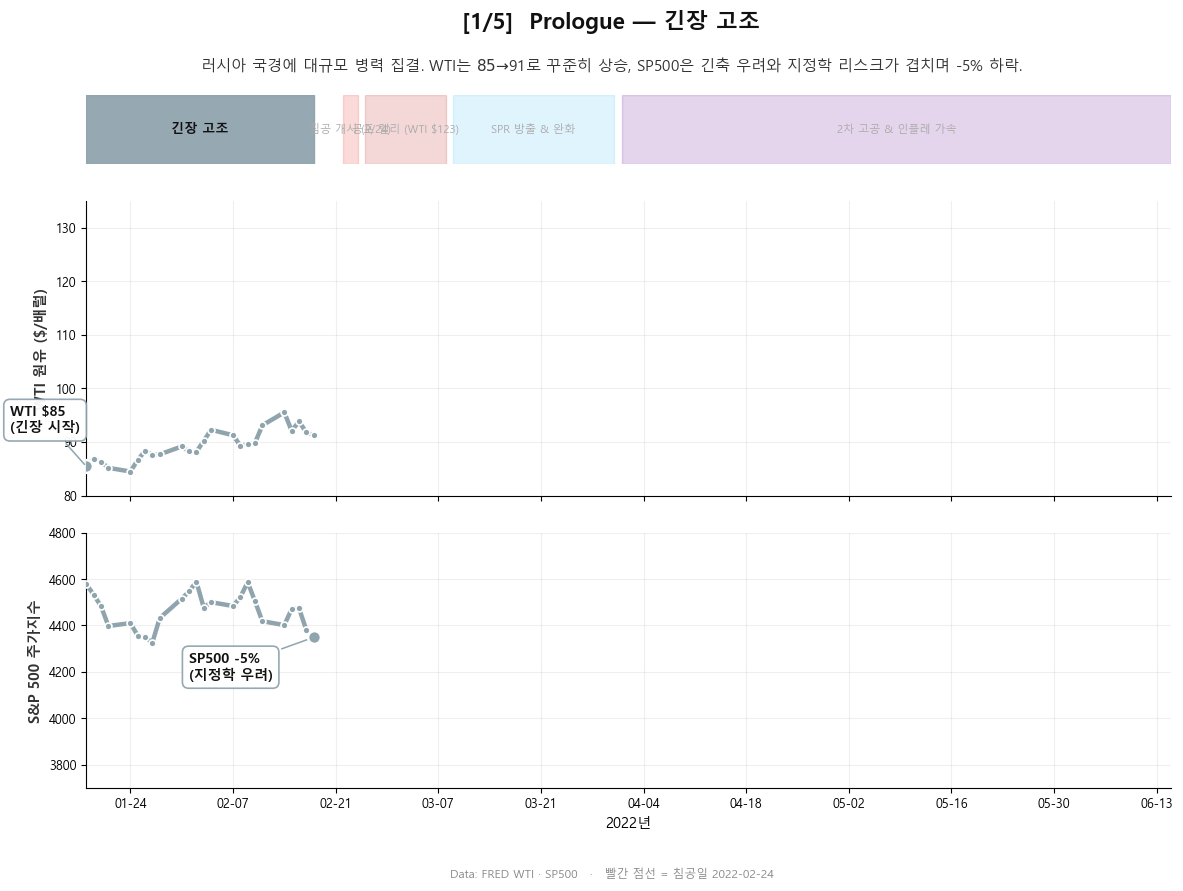

C:\Users\kimch\AppData\Local\Temp\ipykernel_3916\2134777970.py:97: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
c:\Users\kimch\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


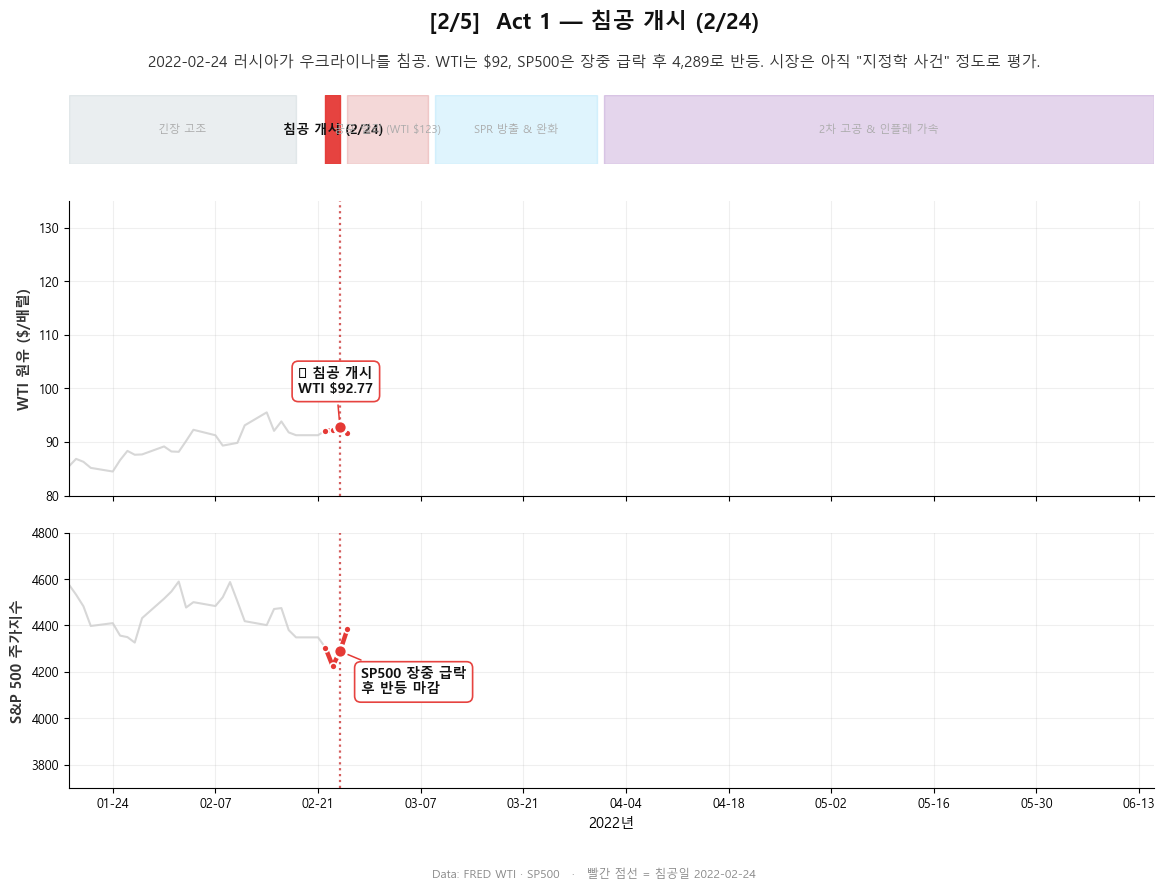

Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not ha

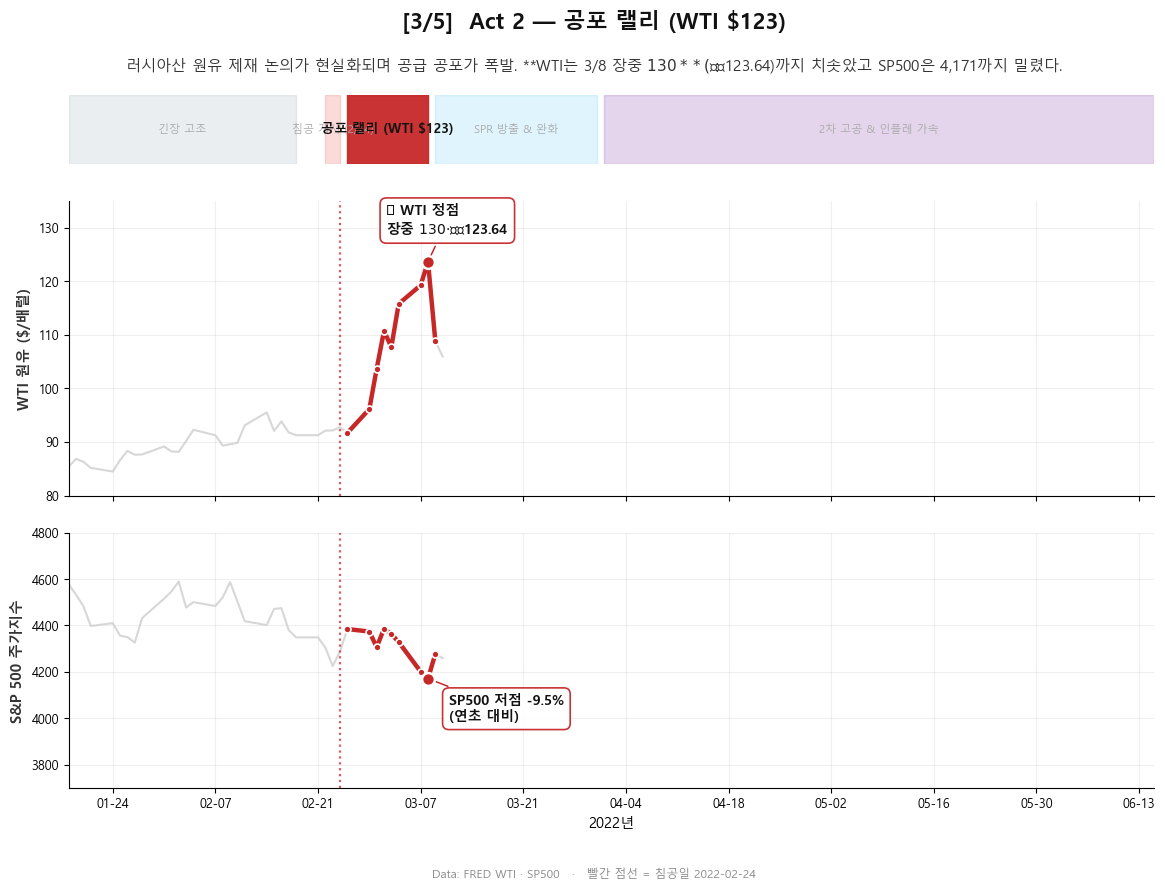

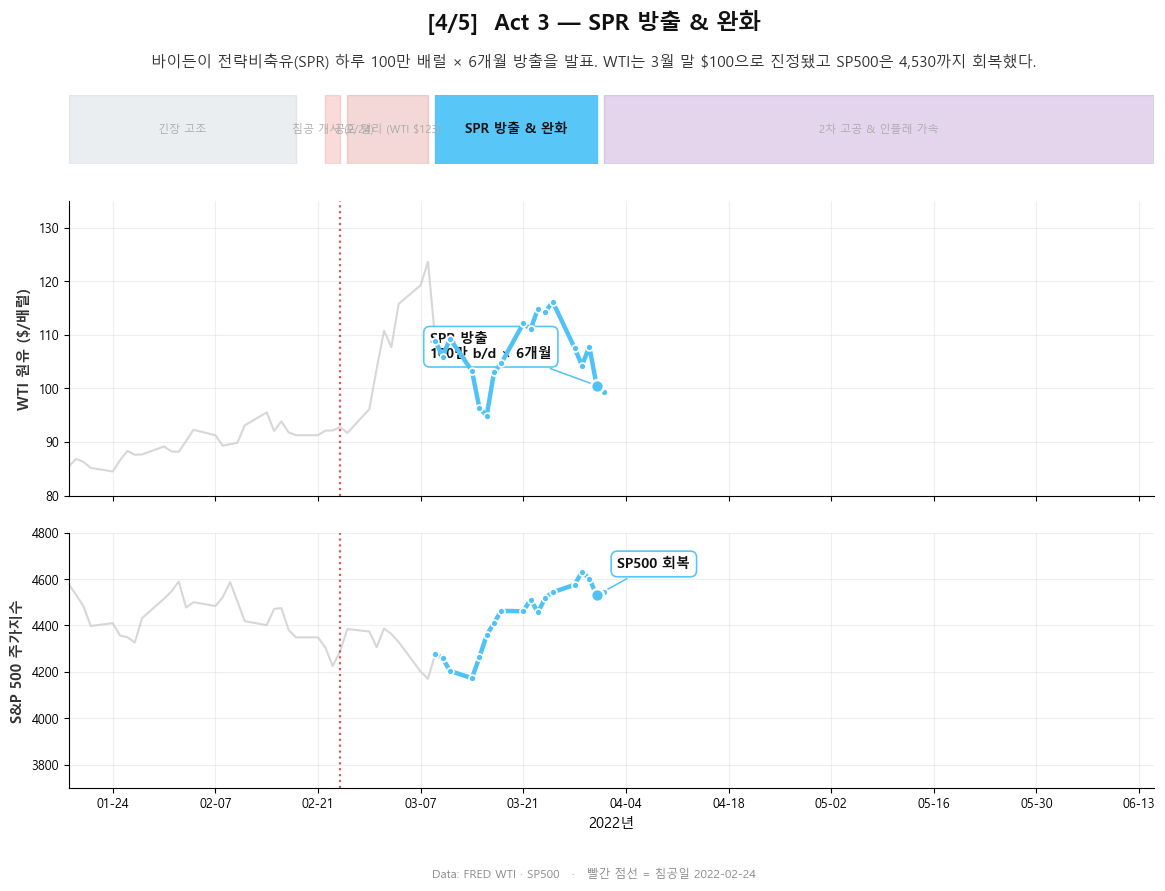

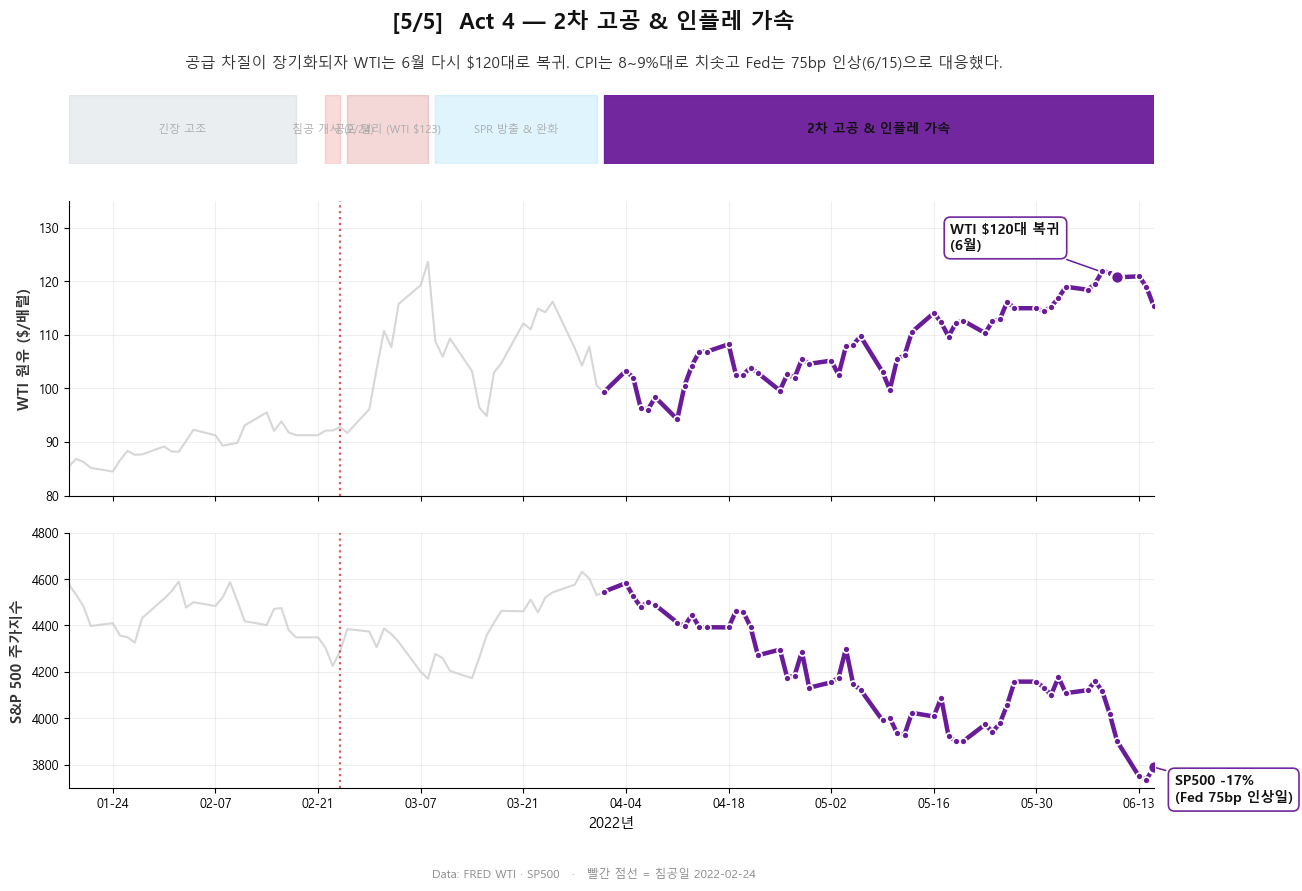

  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\04_act4.png


In [4]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()
for p in saved:
    print(f'  - {p}')

## 5. 종합 프레임

C:\Users\kimch\AppData\Local\Temp\ipykernel_3916\3291914668.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.91])
C:\Users\kimch\AppData\Local\Temp\ipykernel_3916\3291914668.py:62: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uc885' [U+c885], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\uac00' [U+ac00], substituting with a dummy symbol.
Font 'rm' does not have a glyph

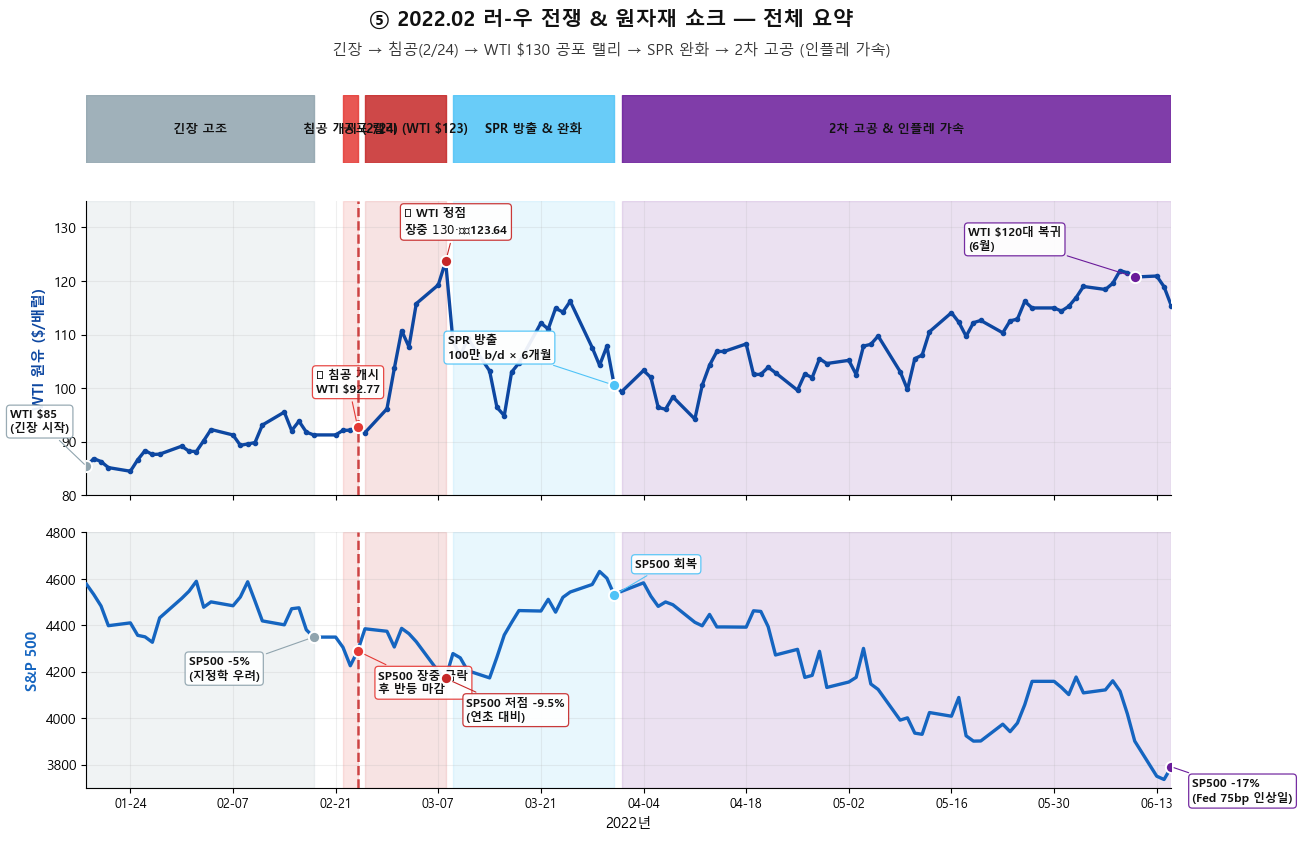


[OK] c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e05_story\99_summary.png


In [5]:
def draw_summary():
    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(3, 1, height_ratios=[0.35, 1.5, 1.3], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_wti = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_sp  = fig.add_subplot(gs[2], sharex=ax_rib)

    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='#111')
        for ax in (ax_wti, ax_sp):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top','right','bottom','left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    fig.suptitle('\u2464 2022.02 러-우 전쟁 & 원자재 쇼크 — 전체 요약',
                 fontsize=15, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.925, '긴장 → 침공(2/24) → WTI $130 공포 랠리 → SPR 완화 → 2차 고공 (인플레 가속)',
             ha='center', fontsize=11, color='#333', style='italic')

    ax_wti.plot(df.index, df['WTI'], color='#0D47A1', lw=2.4, marker='o', markersize=3, zorder=3)
    ax_wti.set_ylabel('WTI 원유 ($/배럴)', fontsize=10.5, fontweight='bold', color='#0D47A1')
    ax_wti.set_ylim(YLIM_WTI)
    ax_sp.plot(df.index, df['SP500'], color='#1565C0', lw=2.4, zorder=3)
    ax_sp.set_ylabel('S&P 500', fontsize=10.5, fontweight='bold', color='#1565C0')
    ax_sp.set_ylim(YLIM_SP)

    for ax in (ax_wti, ax_sp):
        ax.axvline(INVASION, color='#C62828', linestyle='--', lw=1.8, alpha=0.85, zorder=4)
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axmap = {'WTI': ax_wti, 'SP500': ax_sp}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date); c = phase['color']
            ax.scatter([d], [y], s=65, color=c, zorder=6, edgecolors='white', lw=1.4)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8.5,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    ax_sp.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_sp.tick_params(axis='x', labelsize=9)
    ax_sp.set_xlabel('2022년', fontsize=10.5)
    for ax in (ax_rib, ax_wti):
        plt.setp(ax.get_xticklabels(), visible=False)

    plt.tight_layout(rect=[0, 0.02, 1, 0.91])
    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

fig, path = draw_summary()
plt.show()
print(f'\n[OK] {path}')